# Tugas 2 Metode Numerik: Peramalan Harga Emas Antam
**Mata Kuliah:** Metode Numerik (PACS262309) — FMIPA  
**Nama Mahasiswa:** Bimo Ataullah Rahman
**NIM:** 25/556364/PA/23359  
**Metode Komputasi:** Gradient Descent dan Central Finite Difference ($h = 10^{-10}$)  

### Ringkasan Model
Notebook ini membandingkan dua model peramalan deret waktu:
1. **Linear AR(3):** Model regresi 4 parameter ($a_1, a_2, a_3, b$).
2. **Linear Neural Network:** Model jaringan saraf 16 parameter dengan arsitektur $3 \to 3 \to 1$.

### Alur Kerja
1. Siapkan dataset harga emas Antam Januari hingga September 2026.
2. Latih kedua model menggunakan data Januari hingga Agustus 2026 ($N = 243$ hari).
3. Uji prediksi model pada data September 2026 ($N = 30$ hari).
4. Evaluasi performa model dengan metrik RMSE, MAE, dan MAPE.

## 1. Penyiapan Lingkungan Kerja
Jalankan sel ini untuk memeriksa lingkungan eksekusi.
Jika berjalan di Google Colab, perintah ini mengunduh repositori GitHub secara otomatis.
Jika berjalan di komputer lokal, skrip menggunakan berkas kerja aktif.

In [15]:
import os

# Periksa apakah sedang di Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/bimoar07/tugas-metnum-peramalan-emas.git"
    REPO_DIR = "tugas-metnum-peramalan-emas"
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
        %cd {REPO_DIR}
    else:
        %cd {REPO_DIR}
        !git pull
else:
    print("Menjalankan di lingkungan lokal.")

!ls -lh

Menjalankan di lingkungan lokal.
total 304K
-rw-r--r-- 1 bimoar bimoar 3.3K Sep 28 13:28 fetch_data.py
-rw-r--r-- 1 bimoar bimoar  14K Oct  3 20:23 full_jan_sep_2026.csv
-rw-r--r-- 1 bimoar bimoar  66K Oct  3 20:35 history_loss_linear.csv
-rw-r--r-- 1 bimoar bimoar  65K Oct  3 20:33 history_loss_nn.csv
-rw-r--r-- 1 bimoar bimoar 6.4K Sep 29 07:27 linear.cpp
-rwxr-xr-x 1 bimoar bimoar  38K Oct  3 20:23 model_linear
-rwxr-xr-x 1 bimoar bimoar  38K Oct  3 20:24 model_nn
-rw-r--r-- 1 bimoar bimoar 7.3K Oct  3 20:24 nn.cpp
-rw-r--r-- 1 bimoar bimoar   90 Oct  3 20:23 normalization_params.json
-rw-r--r-- 1 bimoar bimoar  15K Oct  3 20:39 notebook_peramalan_emas.ipynb
-rw-r--r-- 1 bimoar bimoar 1.3K Oct  3 20:35 predictions_sep_linear.csv
-rw-r--r-- 1 bimoar bimoar 1.3K Oct  3 20:33 predictions_sep_nn.csv
-rw-r--r-- 1 bimoar bimoar 2.0K Oct  3 20:25 README.md
-rw-r--r-- 1 bimoar bimoar 1.6K Oct  3 20:23 test_sep_2026.csv
-rw-r--r-- 1 bimoar bimoar  13K Oct  3 20:23 train_jan_agu_2026.csv


## 2. Kompilasi dan Eksekusi Program C++
Bagian ini mengompilasi dua berkas sumber C++ dengan bendera optimasi `-O3`.
Program melatih model dengan algoritma Gradient Descent hingga 3000 iterasi.
Program kemudian menyimpan hasil prediksi dan riwayat galat ke berkas CSV.

Daftar program:
1. `linear.cpp`: Menghitung parameter model Linear AR(3).
2. `nn.cpp`: Menghitung 16 parameter model Linear Neural Network.

In [16]:
# Kompilasi kedua engine C++ dengan optimasi -O3
!g++ -O3 linear.cpp -o model_linear
!g++ -O3 nn.cpp -o model_nn

print("\n--- 1. Eksekusi Model Regresi Linear AR(3) ---\n")
!./model_linear

print("\n--- 2. Eksekusi Model Neural Network (16 Parameter) ---\n")
!./model_nn


--- 1. Eksekusi Model Regresi Linear AR(3) ---

Memulai training...
Iter: 1 | Loss: 7.76896 | |Grad|: 144.431
Iter: 200 | Loss: 0.78611 | |Grad|: 0.575057
Iter: 400 | Loss: 0.762971 | |Grad|: 0.445212
Iter: 600 | Loss: 0.745097 | |Grad|: 0.401213
Iter: 800 | Loss: 0.730554 | |Grad|: 0.362253
Iter: 1000 | Loss: 0.718675 | |Grad|: 0.327705
Iter: 1200 | Loss: 0.708935 | |Grad|: 0.297054
Iter: 1400 | Loss: 0.700916 | |Grad|: 0.269834
Iter: 1600 | Loss: 0.694285 | |Grad|: 0.245628
Iter: 1800 | Loss: 0.688779 | |Grad|: 0.224088
Iter: 2000 | Loss: 0.684187 | |Grad|: 0.204876
Iter: 2200 | Loss: 0.68034 | |Grad|: 0.187735
Iter: 2400 | Loss: 0.677102 | |Grad|: 0.172398
Iter: 2600 | Loss: 0.674367 | |Grad|: 0.158656
Iter: 2800 | Loss: 0.672045 | |Grad|: 0.146325
Iter: 3000 | Loss: 0.670066 | |Grad|: 0.135225
Selesai! a1=0.191639 a2=0.11083 a3=0.661452 b=0.01769 E=0.670066
Hasil tersimpan di predictions_sep_linear.csv dan history_loss_linear.csv

--- 2. Eksekusi Model Neural Network (16 Parameter

## 3. Visualisasi Hasil dan Analisis Perbandingan
Bagian ini memuat pustaka Python dan berkas keluaran C++.
Data masukan mencakup data latih, data uji, riwayat galat, dan hasil prediksi.

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Load dataset utama
df_train = pd.read_csv("train_jan_agu_2026.csv")
df_test  = pd.read_csv("test_sep_2026.csv")
df_full  = pd.read_csv("full_jan_sep_2026.csv")

# Load hasil prediksi & log loss kedua model
df_pred_lin = pd.read_csv("predictions_sep_linear.csv")
df_loss_lin = pd.read_csv("history_loss_linear.csv")

df_pred_nn  = pd.read_csv("predictions_sep_nn.csv")
df_loss_nn  = pd.read_csv("history_loss_nn.csv")

print(f"Data Latih: {len(df_train)} hari | Data Uji September: {len(df_test)} hari penuh")
print(f"Prediksi Linear: {len(df_pred_lin)} baris | Prediksi Neural Net: {len(df_pred_nn)} baris")

Data Latih: 243 hari | Data Uji September: 30 hari penuh
Prediksi Linear: 30 baris | Prediksi Neural Net: 30 baris


### A. Visualisasi Deret Waktu Historis (Januari – September 2026)
Grafik ini menampilkan harga resmi emas batangan Antam 1 gram.
Garis merah putus-putus menandai batas data latih dan data uji pada 31 Agustus 2026.

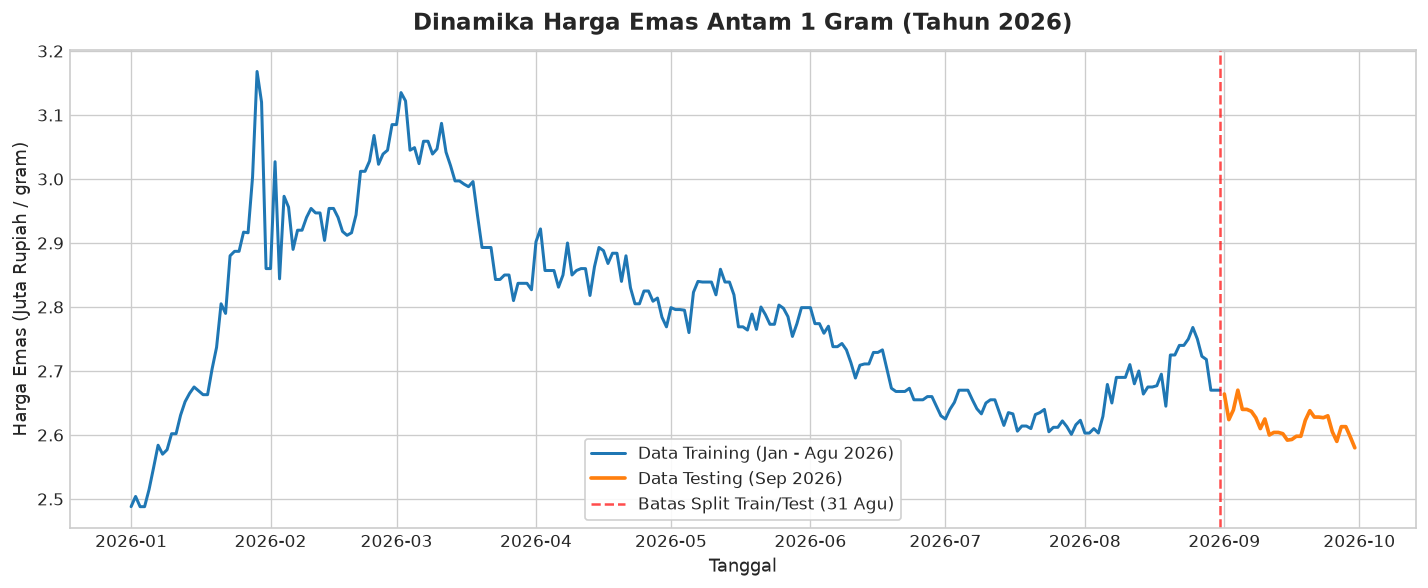

In [18]:
plt.figure(figsize=(12, 5))
dates_train = pd.to_datetime(df_train['date'])
dates_test  = pd.to_datetime(df_test['date'])

plt.plot(dates_train, df_train['price_idr'] / 1e6, label='Data Training (Jan - Agu 2026)', color='#1f77b4', lw=1.8)
plt.plot(dates_test, df_test['price_idr'] / 1e6, label='Data Testing (Sep 2026)', color='#ff7f0e', lw=2.2)
plt.axvline(dates_train.iloc[-1], color='red', linestyle='--', alpha=0.7, label='Batas Split Train/Test (31 Agu)')

plt.title('Dinamika Harga Emas Antam 1 Gram (Tahun 2026)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Tanggal', fontsize=11)
plt.ylabel('Harga Emas (Juta Rupiah / gram)', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

### B. Kurva Konvergensi Pelatihan
Grafik ini membandingkan penurunan nilai SSE dan norma gradien selama pelatihan.
Skala logaritmik memperjelas nilai galat yang mengecil secara stabil.

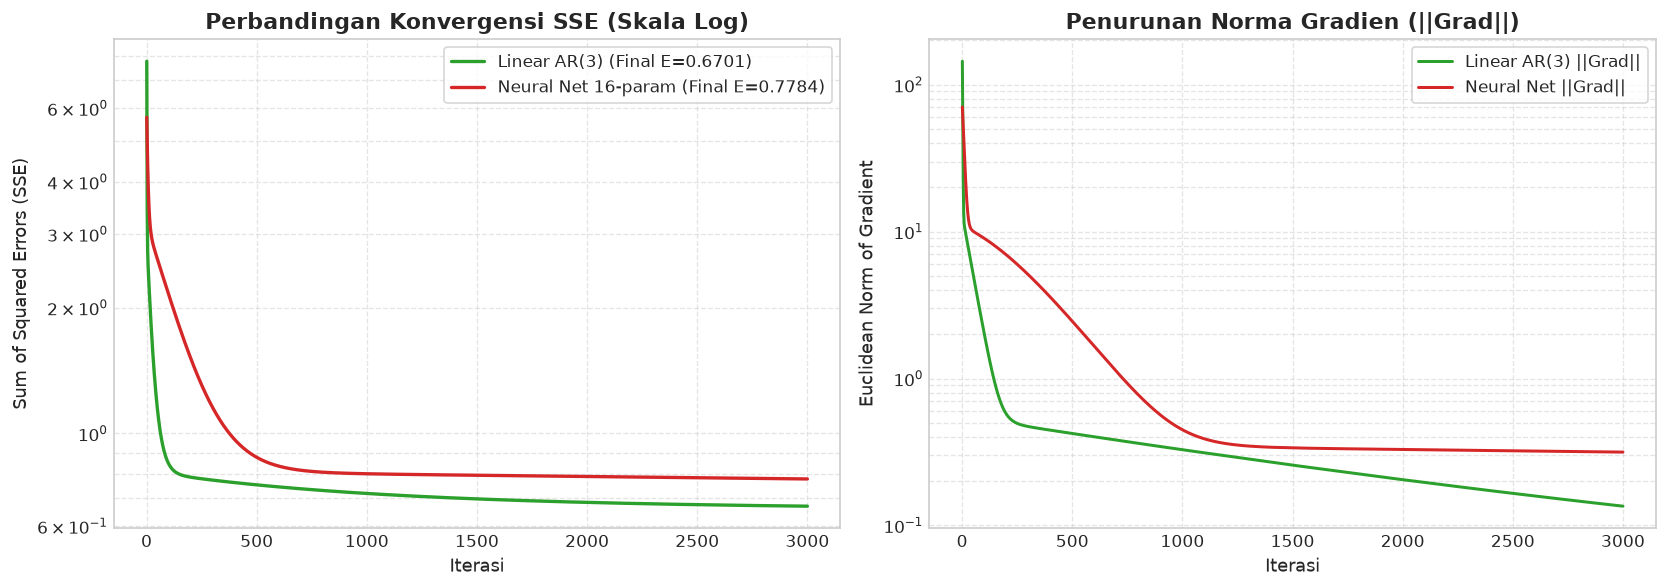

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Perbandingan Konvergensi Loss (SSE) Skala Logaritmik
axes[0].plot(df_loss_lin['iteration'], df_loss_lin['loss'], color='#2ca02c', lw=2, label=f'Linear AR(3) (Final E={df_loss_lin["loss"].iloc[-1]:.4f})')
axes[0].plot(df_loss_nn['iteration'], df_loss_nn['loss'], color='#d62728', lw=2, label=f'Neural Net 16-param (Final E={df_loss_nn["loss"].iloc[-1]:.4f})')
axes[0].set_title('Perbandingan Konvergensi SSE (Skala Log)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Iterasi', fontsize=11)
axes[0].set_ylabel('Sum of Squared Errors (SSE)', fontsize=11)
axes[0].set_yscale('log')
axes[0].legend(frameon=True, facecolor='white')
axes[0].grid(True, which='both', ls='--', alpha=0.5)

# Plot Penurunan Norma Gradien
axes[1].plot(df_loss_lin['iteration'], df_loss_lin['grad_norm'], color='#2ca02c', lw=1.8, label='Linear AR(3) ||Grad||')
axes[1].plot(df_loss_nn['iteration'], df_loss_nn['grad_norm'], color='#d62728', lw=1.8, label='Neural Net ||Grad||')
axes[1].set_title('Penurunan Norma Gradien (||Grad||)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Iterasi', fontsize=11)
axes[1].set_ylabel('Euclidean Norm of Gradient', fontsize=11)
axes[1].set_yscale('log')
axes[1].legend(frameon=True, facecolor='white')
axes[1].grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

### C. Perbandingan Hasil Peramalan Bulan September 2026
Grafik ini membandingkan tiga kurva harga untuk masing-masing model:
1. **Harga Aktual:** Data riil pasar Antam bulan September 2026.
2. **Walk-Forward:** Prediksi satu langkah ke depan memakai data riil 3 hari sebelumnya.
3. **Closed-Loop Rollout:** Prediksi mandiri secara rekursif selama 30 hari tanpa data riil.

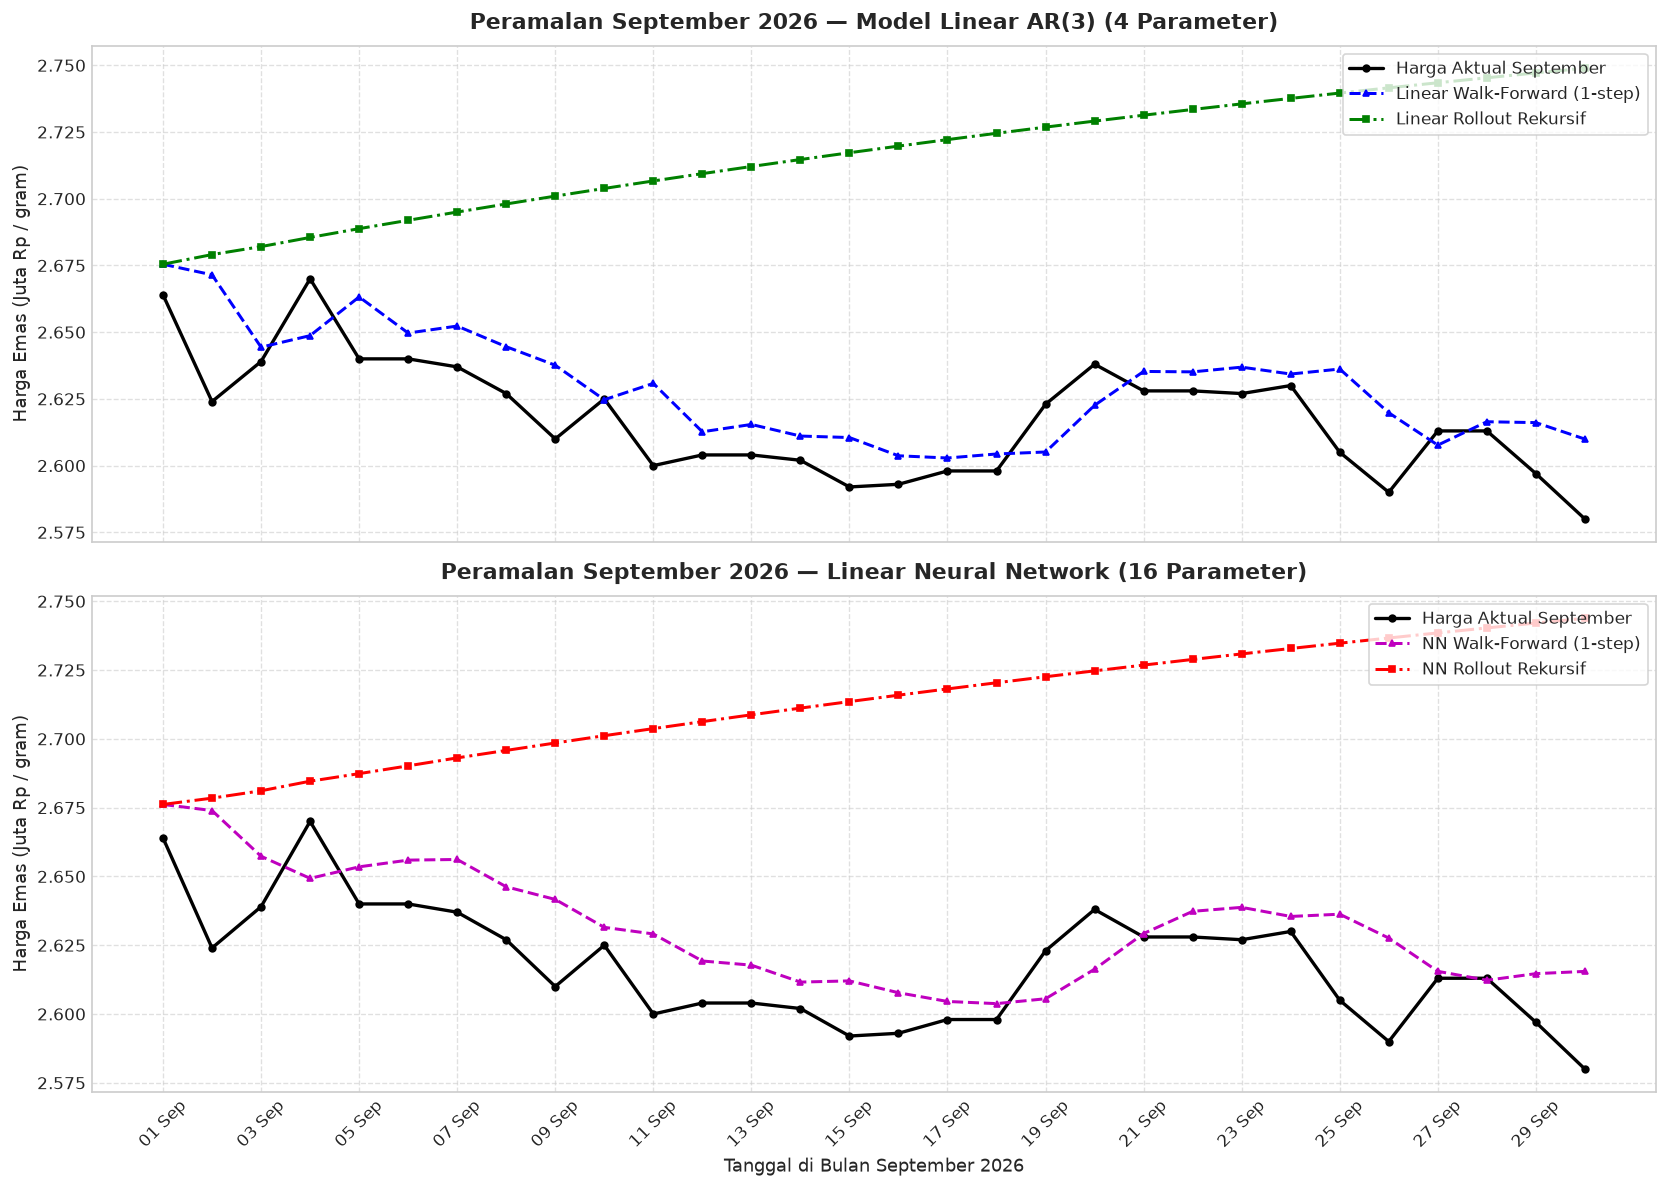

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
dates = pd.to_datetime(df_pred_lin['date'])

# Subplot 1: Model Linear AR(3)
axes[0].plot(dates, df_pred_lin['actual_price_idr'] / 1e6, 'ko-', lw=2, markersize=4, label='Harga Aktual September')
axes[0].plot(dates, df_pred_lin['pred_walkforward_idr'] / 1e6, 'b^--', lw=1.8, markersize=4, label='Linear Walk-Forward (1-step)')
axes[0].plot(dates, df_pred_lin['pred_rollout_idr'] / 1e6, 'gs-.', lw=1.8, markersize=4, label='Linear Rollout Rekursif')
axes[0].set_title('Peramalan September 2026 — Model Linear AR(3) (4 Parameter)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Harga Emas (Juta Rp / gram)', fontsize=11)
axes[0].legend(loc='upper right', frameon=True, facecolor='white')
axes[0].grid(True, ls='--', alpha=0.6)

# Subplot 2: Model Neural Network (16 Parameter)
axes[1].plot(dates, df_pred_nn['actual_price_idr'] / 1e6, 'ko-', lw=2, markersize=4, label='Harga Aktual September')
axes[1].plot(dates, df_pred_nn['pred_walkforward_idr'] / 1e6, 'm^--', lw=1.8, markersize=4, label='NN Walk-Forward (1-step)')
axes[1].plot(dates, df_pred_nn['pred_rollout_idr'] / 1e6, 'rs-.', lw=1.8, markersize=4, label='NN Rollout Rekursif')
axes[1].set_title('Peramalan September 2026 — Linear Neural Network (16 Parameter)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Tanggal di Bulan September 2026', fontsize=11)
axes[1].set_ylabel('Harga Emas (Juta Rp / gram)', fontsize=11)
axes[1].legend(loc='upper right', frameon=True, facecolor='white')
axes[1].grid(True, ls='--', alpha=0.6)

plt.xticks(dates[::2], [d.strftime('%d %b') for d in dates[::2]], rotation=45)
plt.tight_layout()
plt.show()

### D. Tabel Evaluasi Metrik Galat Numerik
Bagian ini menghitung tiga metrik galat pada data uji 30 hari:
- **RMSE:** Mengukur deviasi standar dari galat prediksi.
- **MAE:** Mengukur rata-rata selisih mutlak antara nilai prediksi dan aktual.
- **MAPE:** Mengukur persentase rata-rata galat relatif terhadap harga aktual.

In [21]:
def calculate_metrics(actual, pred):
    diff = actual - pred
    rmse = np.sqrt(np.mean(diff**2))
    mape = np.mean(np.abs(diff / actual)) * 100.0
    mae  = np.mean(np.abs(diff))
    return rmse, mae, mape

# Metrik Linear AR(3)
rmse_l_wf, mae_l_wf, mape_l_wf = calculate_metrics(df_pred_lin['actual_price_idr'], df_pred_lin['pred_walkforward_idr'])
rmse_l_ro, mae_l_ro, mape_l_ro = calculate_metrics(df_pred_lin['actual_price_idr'], df_pred_lin['pred_rollout_idr'])

# Metrik Neural Network (16 Parameter)
rmse_nn_wf, mae_nn_wf, mape_nn_wf = calculate_metrics(df_pred_nn['actual_price_idr'], df_pred_nn['pred_walkforward_idr'])
rmse_nn_ro, mae_nn_ro, mape_nn_ro = calculate_metrics(df_pred_nn['actual_price_idr'], df_pred_nn['pred_rollout_idr'])

metrics_table = pd.DataFrame({
    'Model': [
        'Linear AR(3)', 
        'Linear AR(3)', 
        'Neural Network (16 Param)', 
        'Neural Network (16 Param)'
    ],
    'Mode Prediksi': [
        'Walk-Forward (1-Step)', 
        'Closed-Loop Rollout',
        'Walk-Forward (1-Step)', 
        'Closed-Loop Rollout'
    ],
    'RMSE (IDR)': [
        f"Rp {rmse_l_wf:,.2f}", 
        f"Rp {rmse_l_ro:,.2f}",
        f"Rp {rmse_nn_wf:,.2f}", 
        f"Rp {rmse_nn_ro:,.2f}"
    ],
    'MAE (IDR)': [
        f"Rp {mae_l_wf:,.2f}", 
        f"Rp {mae_l_ro:,.2f}",
        f"Rp {mae_nn_wf:,.2f}", 
        f"Rp {mae_nn_ro:,.2f}"
    ],
    'MAPE (%)': [
        f"{mape_l_wf:.3f}%", 
        f"{mape_l_ro:.3f}%",
        f"{mape_nn_wf:.3f}%", 
        f"{mape_nn_ro:.3f}%"
    ]
})

print("=" * 80)
print("TABEL EVALUASI PERBANDINGAN PERFORMA MODEL PADA DATA UJI SEPTEMBER 2026 (30 HARI)")
print("=" * 80)
metrics_table

TABEL EVALUASI PERBANDINGAN PERFORMA MODEL PADA DATA UJI SEPTEMBER 2026 (30 HARI)


,Model,Mode Prediksi,RMSE (IDR),MAE (IDR),MAPE (%)
0,Linear AR(3),Walk-Forward (1-Step),"Rp 18,712.71","Rp 15,346.93",0.587%
1,Linear AR(3),Closed-Loop Rollout,"Rp 105,548.52","Rp 98,269.50",3.765%
2,Neural Network (16 Param),Walk-Forward (1-Step),"Rp 20,560.82","Rp 17,139.40",0.655%
3,Neural Network (16 Param),Closed-Loop Rollout,"Rp 101,928.94","Rp 94,935.50",3.637%


### E. Kesimpulan dan Pembahasan Numerik

#### 1. Performa Mode Prediksi
- Mode Walk-Forward menghasilkan nilai MAPE di bawah 0.70% pada kedua model.
- Model Linear AR(3) mencapai RMSE Rp 18.712,71 pada mode Walk-Forward.
- Model Neural Network mencapai RMSE Rp 20.560,82 pada mode Walk-Forward.
- Mode Rollout mengalami penumpukan galat karena prediksi baru memakai hasil prediksi lama.
- Nilai MAPE mode Rollout tetap berada di bawah 3.80% untuk horizon 30 hari.

#### 2. Karakteristik Kurva Rollout
- Kurva Rollout naik secara bertahap dan mulus tanpa fluktuasi harian.
- Model tidak menerima syok pasar harian saat berjalan dalam mode tertutup.
- Sistem persamaan beda memiliki akar karakteristik dominan bernilai riil positif ($\lambda_1 \approx 0.976$).
- Kurva bergerak mendekati titik kesetimbangan jangka panjang pada kisaran Rp 2.821.000.

#### 3. Perbandingan Model dan Optimasi
- Central Finite Difference dengan $h = 10^{-10}$ memberikan gradien numerik yang stabil.
- Nilai galat SSE Linear AR(3) turun hingga 0.670 pada iterasi 3000.
- Nilai galat SSE Linear Neural Network turun hingga 0.778 pada iterasi 3000.
- Neural Network mencapai performa Rollout lebih baik dengan RMSE Rp 101.928,94.
- Normalisasi rentang 0 hingga 1 mencegah ketidakstabilan numerik selama pelatihan.